# Week 3 Notebook 2: The first ten minutes with any dataset

**CSC: Data Analytics, Data Mining and Machine Learning**

Every dataset you meet gets the same opening routine. Before modelling or answering a research question, first learn what you actually have.

### Today’s routine
**Size -> rows -> column types -> missing values -> duplicates -> numerical summaries -> distributions -> relationships**

The examples use the Palmer Penguins dataset because it is small, real, and contains common data-quality issues.

## Setup

In [4]:
# pandas: tables and data cleaning; numpy: numerical operations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and chart defaults for the rest of the notebook.
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## Load the data

This notebook uses the **Palmer Penguins** dataset: 344 penguins measured at Palmer Station, Antarctica. It is small, real, and messy in all the usual ways.

Your group's data may not be a CSV file. Pandas can read several common table formats. Choose the reader that matches the file you have:

| File type | Pandas reader |
| --- | --- |
| CSV | `pd.read_csv(...)` |
| TSV or other separated text | `pd.read_csv(..., sep="\t")` |
| Excel | `pd.read_excel(...)` |
| JSON | `pd.read_json(...)` |
| Parquet | `pd.read_parquet(...)` |

Run the penguins example first. Then replace `file_path` and uncomment one alternative reader for your own data. Excel and Parquet files may need an additional package installed in your Python environment.

In [7]:
# Load the file into a pandas DataFrame called df.
file_path = r"C:\Users\claud\OneDrive\4th year\CSC1171 project idea 1\darren data\extracted_data\mmv_ChEMBL-IC50s-Sep2026.csv"

df = pd.read_csv(file_path, sep="\t")
# For another file, replace file_path and use the matching reader:
# df = pd.read_csv("../data/your_file.tsv", sep="\t")
# df = pd.read_excel("../data/your_file.xlsx")
# df = pd.read_json("../data/your_file.json")
# df = pd.read_parquet("../data/your_file.parquet")

# Preview the first five rows to check that the file loaded as expected.
df.head()

,chembl_id,pref_name,smiles,molecular_weight,logp,hba,hbd,psa,rtb,ro5_violations,aromatic_rings,heavy_atoms,pf_ec50_uM,tb_ic50_uM,tc_ic50_uM,tbrucei_ic50_uM,ld_ic50_uM,cp_ec50_uM,tg_ec50_uM,hepg2_cc50_uM,si_pf,si_tb,si_tc,si_tbrucei,si_ld,si_cp,si_tg
0,CHEMBL3473319,NaN,NCC1CCCN(c2nc(-c3ccccc3)nc3c2CCNCC3)C1,337.47,2.01,5.0,2.0,67.07,3.0,0.0,2.0,25.0,NaN,NaN,NaN,NaN,27.2331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL3497966,NaN,COc1ccc(-c2ccc(C3CNCCO3)nc2)cc1.Cl,306.79,2.42,4.0,1.0,43.38,3.0,0.0,2.0,20.0,0.1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEMBL3497629,NaN,COc1ccccc1C1(NCc2c(C)nc3c(C)cccn23)CCCC1.Cl,385.94,4.52,4.0,1.0,38.56,5.0,0.0,3.0,26.0,0.7058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHEMBL529068,NaN,CC(C)(CN)c1nc(-c2ccc(Cl)c(O)c2)c(-c2ccnc(N)n2)...,358.83,2.71,6.0,4.0,126.73,4.0,0.0,3.0,25.0,0.4143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHEMBL4932697,NaN,COc1cccc(N2C(=O)C[C@]3(CC3(c3ccccc3)c3ccccc3)C...,383.45,4.33,3.0,0.0,46.61,4.0,0.0,3.0,29.0,2.4510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Move 1: How big is it?

Start with the number of **rows and columns**. If the size surprises you, stop and find out why.

In [8]:
# shape returns (number_of_rows, number_of_columns).
print("rows, columns:", df.shape)

rows, columns: (2452, 27)


## Move 2: What does a row look like?

Look at a few rows. This helps you understand what one observation represents and whether the values look sensible.

In [9]:
# head() shows the first five rows of the table.
df.head()

,chembl_id,pref_name,smiles,molecular_weight,logp,hba,hbd,psa,rtb,ro5_violations,aromatic_rings,heavy_atoms,pf_ec50_uM,tb_ic50_uM,tc_ic50_uM,tbrucei_ic50_uM,ld_ic50_uM,cp_ec50_uM,tg_ec50_uM,hepg2_cc50_uM,si_pf,si_tb,si_tc,si_tbrucei,si_ld,si_cp,si_tg
0,CHEMBL3473319,NaN,NCC1CCCN(c2nc(-c3ccccc3)nc3c2CCNCC3)C1,337.47,2.01,5.0,2.0,67.07,3.0,0.0,2.0,25.0,NaN,NaN,NaN,NaN,27.2331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL3497966,NaN,COc1ccc(-c2ccc(C3CNCCO3)nc2)cc1.Cl,306.79,2.42,4.0,1.0,43.38,3.0,0.0,2.0,20.0,0.1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEMBL3497629,NaN,COc1ccccc1C1(NCc2c(C)nc3c(C)cccn23)CCCC1.Cl,385.94,4.52,4.0,1.0,38.56,5.0,0.0,3.0,26.0,0.7058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHEMBL529068,NaN,CC(C)(CN)c1nc(-c2ccc(Cl)c(O)c2)c(-c2ccnc(N)n2)...,358.83,2.71,6.0,4.0,126.73,4.0,0.0,3.0,25.0,0.4143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHEMBL4932697,NaN,COc1cccc(N2C(=O)C[C@]3(CC3(c3ccccc3)c3ccccc3)C...,383.45,4.33,3.0,0.0,46.61,4.0,0.0,3.0,29.0,2.4510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Move 3: What type is each column?

The single most common data bug: a number stored as text. Use `.info()` to check the data types and whether columns contain missing values.

In [10]:
# info() shows column names, data types, and non-missing value counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2452 entries, 0 to 2451
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chembl_id         2452 non-null   str    
 1   pref_name         86 non-null     str    
 2   smiles            2452 non-null   str    
 3   molecular_weight  2452 non-null   float64
 4   logp              2447 non-null   float64
 5   hba               2447 non-null   float64
 6   hbd               2447 non-null   float64
 7   psa               2447 non-null   float64
 8   rtb               2447 non-null   float64
 9   ro5_violations    2447 non-null   float64
 10  aromatic_rings    2447 non-null   float64
 11  heavy_atoms       2447 non-null   float64
 12  pf_ec50_uM        1687 non-null   float64
 13  tb_ic50_uM        377 non-null    float64
 14  tc_ic50_uM        441 non-null    float64
 15  tbrucei_ic50_uM   469 non-null    float64
 16  ld_ic50_uM        198 non-null    float64
 17  cp_ec5

## Move 4: What is missing?

Counts tell you how much is missing; percentages make it easier to compare columns of different sizes.

Missing data is not automatically an error. First find out **where it is missing and why** before deciding what to do with it.

In [11]:
# Count missing cells in each column.
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})

# Sort so the columns needing the most attention appear first.
missing.sort_values("n_missing", ascending=False)

,n_missing,pct_missing
si_cp,2450,99.9
si_tg,2445,99.7
si_ld,2434,99.3
si_tb,2434,99.3
cp_ec50_uM,2413,98.4
si_tc,2411,98.3
si_tbrucei,2392,97.6
tg_ec50_uM,2375,96.9
pref_name,2366,96.5
si_pf,2361,96.3


### A question worth asking

Are the missing values scattered through the dataset, or do they occur in particular groups or parts of the file? A pattern in missingness can tell you something about how the data were collected.

    The missing values are not spread evenly across the dataset. Some specific columns have a lot of missing data, while others have very little or none. This suggests that some measurements were only collected for certain compounds.

---
## Move 5: Duplicates

Exact duplicate rows can indicate a data-processing problem. Check them before analysing the data.

In [12]:
# duplicated() marks rows that are exact copies of an earlier row.
# sum() counts how many duplicate rows were found.
print("exact duplicate rows:", df.duplicated().sum())

exact duplicate rows: 0


---
## Move 6: Summarise the numbers

`.describe()` gives count, mean, standard deviation, minimum, quartiles and maximum for numeric columns.

**Look at the minimum and maximum first.** They can reveal impossible or suspicious values before the average hides them.

    Most of the molecular properties have reasonable ranges, but some assay values have very large maximum values compared with their median. This suggests there may be some extreme values or outliers that should be checked.

In [13]:
# describe() calculates common summaries for numeric columns.
# Transpose so each variable appears as a row, which is easier to read.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
molecular_weight,2452.0,366.661158,83.195328,123.1100,317.702500,349.51000,401.06000,1297.3000
logp,2447.0,3.456535,1.350105,-2.5600,2.565000,3.39000,4.20000,10.4500
hba,2447.0,4.568860,1.570130,0.0000,3.000000,4.00000,6.00000,17.0000
hbd,2447.0,1.241929,0.924982,0.0000,1.000000,1.00000,2.00000,12.0000
psa,2447.0,61.328394,24.792332,3.2400,43.080000,59.50000,76.19000,319.6100
rtb,2447.0,4.669800,2.048991,0.0000,3.000000,5.00000,6.00000,20.0000
ro5_violations,2447.0,0.154884,0.439421,0.0000,0.000000,0.00000,0.00000,3.0000
aromatic_rings,2447.0,2.555783,0.989754,0.0000,2.000000,2.00000,3.00000,9.0000
heavy_atoms,2447.0,25.295872,5.374670,9.0000,22.000000,25.00000,27.00000,65.0000
pf_ec50_uM,1687.0,5.214370,73.266294,0.0043,0.630600,1.15370,2.67290,2620.8002


---
## Move 7: Look at the distributions

Now connect this notebook to the previous one: use histograms to see the shape of every numeric variable.

Look for:
- skew
- multiple peaks
- gaps
- suspicious spikes
- values that look impossible

You do not need to interpret every detail yet. The goal is to notice what deserves a closer look.

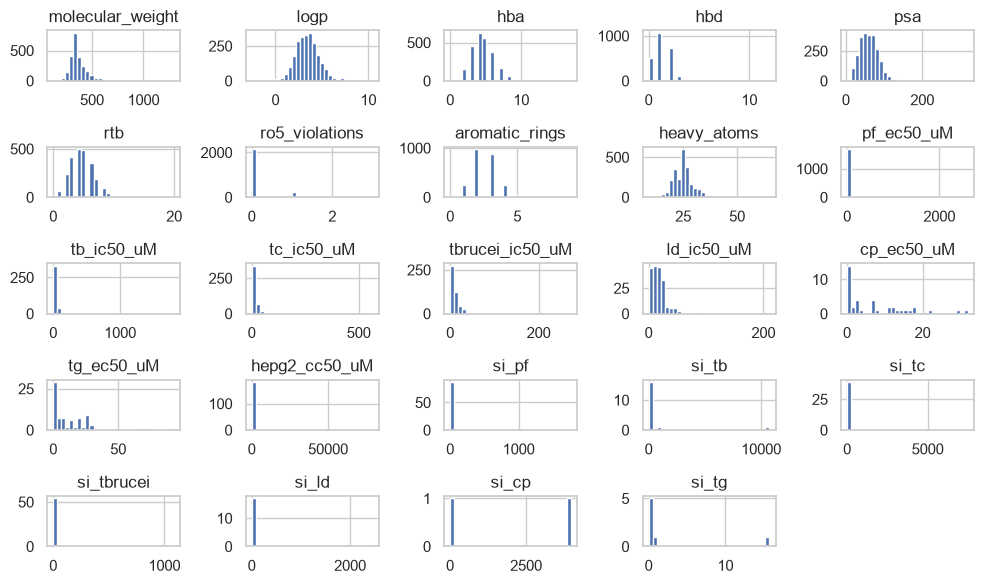

In [14]:
# Select numeric columns and draw one histogram for each.
df.select_dtypes("number").hist(figsize=(10, 6), bins=30, edgecolor="white")
plt.tight_layout()
plt.show()

### One thing to notice

Look at `bill_depth_mm`. It does not look like one simple hump. A distribution can contain multiple groups mixed together, which is one reason that **grouping variables matter**.

---
## Move 8: How do the numbers relate?

A correlation matrix is a fast first pass for numeric variables. In this notebook, pandas uses **Pearson correlation** by default. Pearson correlation measures the strength and direction of a **linear relationship**: whether larger values of one variable tend to occur with larger or smaller values of another variable in a roughly straight-line pattern.

Pearson correlation ranges from `-1` to `1`:

- `1` means a perfect positive linear relationship;
- `-1` means a perfect negative linear relationship; and
- `0` means no linear relationship.

A value near `0` does not prove that there is no relationship. A curved relationship can have a small Pearson correlation. Treat this matrix as a screening tool, then inspect a scatter plot.

Other correlation measures answer slightly different questions. **Spearman correlation** compares the ranks of values and is useful for a consistently increasing or decreasing relationship that is not straight. **Kendall correlation** also uses ranks and is often useful with smaller datasets or many tied values.

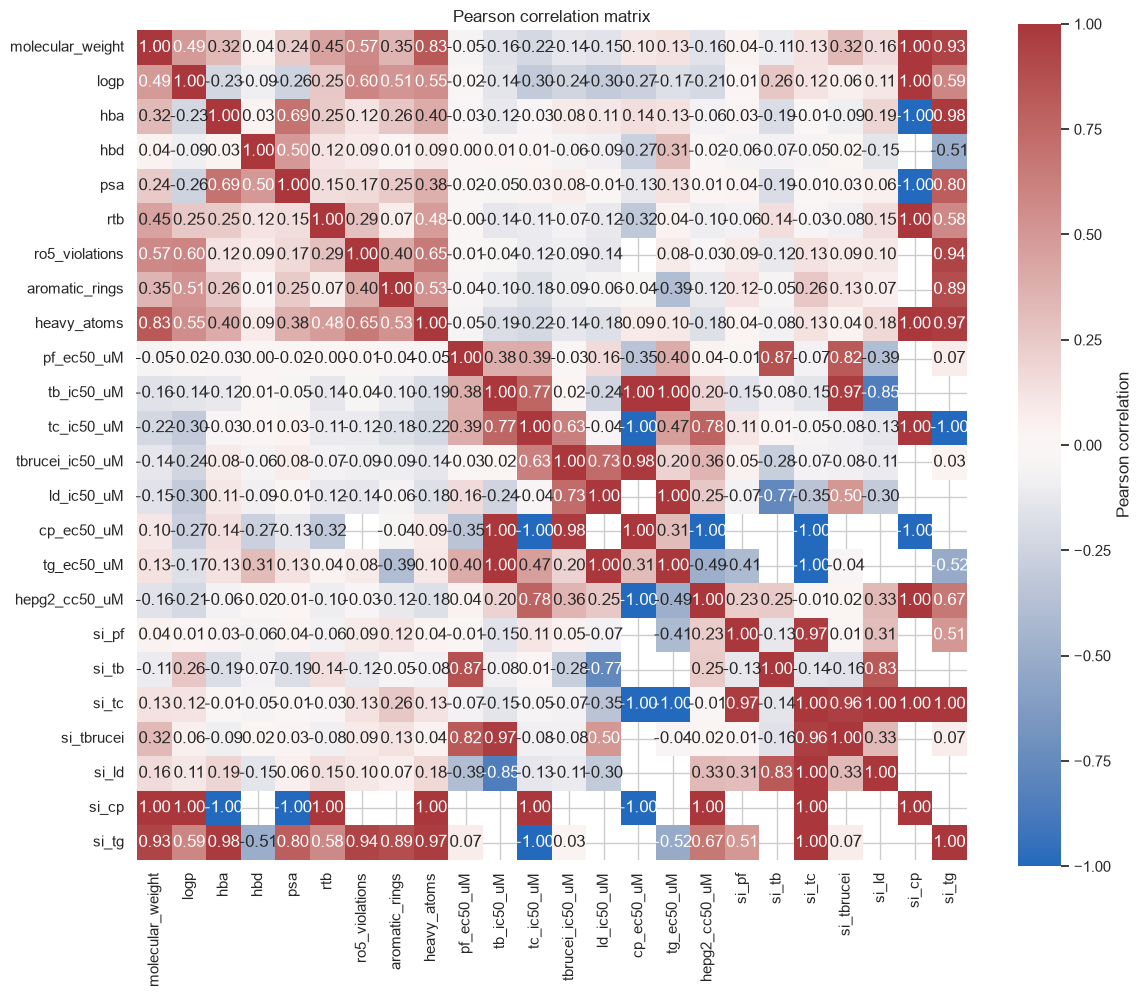

In [17]:
# Select numeric columns and calculate Pearson correlations.
# Pearson is pandas' default method and measures linear relationships.
numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

# A heatmap makes positive and negative relationships easier to scan.
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

## Check your understanding

Use the outputs above to answer these questions about the penguins dataset. Choose or calculate the answers in the next cell.

- How many rows are in the dataset?
- How many columns are in the dataset?
- Which column has the most missing values?
- How many exact duplicate rows are there?
- Which columns contain numeric measurements?

The final cell loads the external checker from the `tests/` folder and tells you whether your answers are correct.

In [11]:
# Replace each None with your answer.
number_of_rows = None
number_of_columns = None
column_with_most_missing = None
duplicate_rows = None
numeric_columns = None

print(number_of_rows, number_of_columns)
print(column_with_most_missing, duplicate_rows)
print(numeric_columns)

None None
None None
None


Run the next cell after filling in your answers. It imports the external test from `tests/` and reports the result without showing the expected answers.

In [12]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd()
if not (project_root / "tests").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import tests.test_first_look as first_look_tests
importlib.reload(first_look_tests)

check_passed = first_look_tests.check_first_look(globals())
print("Passed" if check_passed else "Not passed yet")

Some answers are missing or need another look. Review the dataset outputs and try again.
Not passed yet


---
## Your turn

Take a few minutes to inspect this dataset. Write three short observations:

1. **One thing that surprised you**
2. **One thing that looks potentially wrong or worth checking**
3. **One question you would investigate next**

The aim is not to “solve” the dataset. Good exploratory analysis produces better questions.

In [ ]:
# Your three sentences here (as a comment or a markdown cell: your choice)

## The routine to remember

Use this order when you receive a new dataset:

**How big is it? -> What is one row? -> What are the columns? -> What is missing? -> Are there duplicates? -> What do the numbers look like? -> What relationships are visible?**

Only after this first look should you start making stronger decisions about cleaning, modelling, or statistical analysis.